In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

np.random.seed(42)
t = np.arange(1000)

# 1. Biological Logic: Glucose starts at 10 and is consumed over time
# We use a trend + a small amount of noise
glucose = 10 * np.exp(-0.005 * t) + np.random.normal(0, 0.1, 1000)

# 2. DO (Dissolved Oxygen): Drops as the "cells" grow
do = 100 * np.exp(-0.003 * t) + np.random.normal(0, 0.5, 1000)

# 3. pH: Slowly drifts down as metabolites accumulate
ph = 7.2 - (0.0002 * t) + np.random.normal(0, 0.02, 1000)

# 4. Temp: Stays around 37 but has a "diurnal" oscillation
temp = 37 + 0.2 * np.sin(2 * np.pi * t / 24) + np.random.normal(0, 0.05, 1000)

df = pd.DataFrame({
    'DO': do,
    'pH': ph,
    'Temp': temp,
    'Glucose': glucose
})
df['Glucose'] = df['Glucose'].clip(lower=0.0)

In [2]:
df

,DO,pH,Temp,Glucose
0,100.699678,7.186496,36.904610,10.049671
1,100.162766,7.196910,37.008745,9.936298
2,99.431612,7.183752,37.079320,9.965267
3,98.780569,7.193241,37.235806,10.003422
4,99.156283,7.161328,37.201033,9.778571
...,...,...,...,...
995,5.589025,7.002550,37.053187,0.040975
996,5.025551,7.005955,36.896109,0.248509
997,4.582780,6.975765,36.932221,0.132482
998,4.927135,7.007084,36.982169,0.010939


In [3]:
y = df.iloc[:,-1 ]

In [4]:
y

0      10.049671
1       9.936298
2       9.965267
3      10.003422
4       9.778571
         ...    
995     0.040975
996     0.248509
997     0.132482
998     0.010939
999     0.124975
Name: Glucose, Length: 1000, dtype: float64

In [5]:
X = df.iloc[: , :-1]

In [6]:
X

,DO,pH,Temp
0,100.699678,7.186496,36.904610
1,100.162766,7.196910,37.008745
2,99.431612,7.183752,37.079320
3,98.780569,7.193241,37.235806
4,99.156283,7.161328,37.201033
...,...,...,...
995,5.589025,7.002550,37.053187
996,5.025551,7.005955,36.896109
997,4.582780,6.975765,36.932221
998,4.927135,7.007084,36.982169


In [7]:
train_data = df.iloc[:800 , :]
test_data = df.iloc[800: ,:]

In [8]:
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [9]:
train_scaled[10 , 3]

np.float64(0.94175772623185)

In [10]:
def prep(data , window):
    X , y = [] ,[]
    for i in range(len(data) - window):
        X.append(data[i:i+window , :3])
        y.append(data[i+window,3])
    return np.array(X)  , np.array(y)

X_train , y_train = prep(train_scaled , 10)
X_test , y_test = prep(test_scaled , 10)

In [11]:
X_train.shape

(790, 10, 3)

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset

In [13]:
X_train_tensor = torch.tensor(X_train , dtype = torch.float32)
y_train_tensor  = torch.tensor(y_train , dtype = torch.float32).view(-1 , 1)
X_test_tensor = torch.tensor(X_test , dtype = torch.float32)
y_test_tensor = torch.tensor(y_test , dtype = torch.float32).view(-1, 1)

In [14]:
X_train_tensor.shape

torch.Size([790, 10, 3])

In [15]:
train_ds = TensorDataset(X_train_tensor ,y_train_tensor)
test_ds = TensorDataset(X_test_tensor , y_test_tensor)

In [16]:
train_loader = DataLoader(train_ds , batch_size=64)
test_loader = DataLoader(test_ds , batch_size=64)

In [17]:
# Check for Apple Silicon GPU (MPS)
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("M4 GPU (MPS) is available! 🚀")
else:
    device = torch.device("cpu")
    print("MPS not available, using CPU.")

M4 GPU (MPS) is available! 🚀


In [18]:
class LSTM(nn.Module):
    def __init__(self , input , hidden_size , num_layers):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input , hidden_size , num_layers , batch_first = True , dropout=0.3)
        self.fc = nn.Linear(hidden_size , 1)

    def forward(self , x):
        h0 = torch.zeros(self.num_layers , x.size(0) , self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        out , (hn , cn)= self.lstm(x , (h0 , c0))
        out = out[: , -1 , :]
        return torch.sigmoid(self.fc(out)) * 0.2


In [19]:
model = LSTM(3 , 32 , 2)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.003, weight_decay=1e-6)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=30)
model.to(device)


LSTM(
  (lstm): LSTM(3, 32, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

In [20]:
epochs = 400
model_loss = []

for epoch in range(epochs):
    running_loss = 0.0
    model.train()
    for X_batch , y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        out  = model(X_batch)
        loss = criterion(out , y_batch)
        running_loss  = loss.item() + running_loss
        loss.backward()
        optimizer.step()
    avg_loss = running_loss/len(train_loader)
    scheduler.step(avg_loss)
    model_loss.append(avg_loss)
    print(f"Epoch : {epoch+1} | Loss : {avg_loss}")

Epoch : 1 | Loss : 0.07470040373468342
Epoch : 2 | Loss : 0.06913318510543412
Epoch : 3 | Loss : 0.06352321345072526
Epoch : 4 | Loss : 0.0598911468584377
Epoch : 5 | Loss : 0.0555176274636044
Epoch : 6 | Loss : 0.056424628681270406
Epoch : 7 | Loss : 0.04874459519767417
Epoch : 8 | Loss : 0.047956723570957996
Epoch : 9 | Loss : 0.04827164712164981
Epoch : 10 | Loss : 0.04815048636653675
Epoch : 11 | Loss : 0.05402338941796468
Epoch : 12 | Loss : 0.04693863145299614
Epoch : 13 | Loss : 0.047711271029234364
Epoch : 14 | Loss : 0.04670176802420219
Epoch : 15 | Loss : 0.046453177932282694
Epoch : 16 | Loss : 0.04640932447084477
Epoch : 17 | Loss : 0.0463712608437233
Epoch : 18 | Loss : 0.04633486734103197
Epoch : 19 | Loss : 0.04630570426189269
Epoch : 20 | Loss : 0.046282860492982976
Epoch : 21 | Loss : 0.0462641915342269
Epoch : 22 | Loss : 0.046248453833798595
Epoch : 23 | Loss : 0.0462347505269393
Epoch : 24 | Loss : 0.04622282866666165
Epoch : 25 | Loss : 0.046212433318522435
Epoch :

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

Text(0, 0.5, 'Loss')

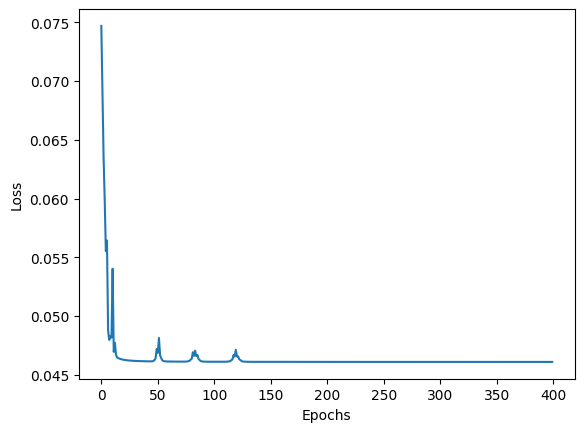

In [22]:
plt.plot(model_loss)
plt.xlabel("Epochs")
plt.ylabel("Loss")

# EVALUATION

In [23]:
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

model.eval()
with torch.no_grad():
    # Get scaled predictions (shape: [batch, 1])
    preds_scaled = model(X_test_tensor.to(device)).cpu().numpy().flatten()   # 1D array

# === IMPORTANT: Create dummy with SAME shape & order as original scaled data ===
n_samples = len(preds_scaled)
dummy_for_preds = np.zeros((n_samples, 4))          # columns: DO=0, pH=1, Temp=2, Glucose=3
dummy_for_preds[:, 3] = preds_scaled               # put model output ONLY in Glucose column

# Inverse transform → take ONLY the Glucose column back to original scale
preds_real = scaler.inverse_transform(dummy_for_preds)[:, 3]

# Do the same for true targets (y_test_tensor is already scaled)
dummy_for_true = np.zeros((n_samples, 4))
dummy_for_true[:, 3] = y_test_tensor.cpu().numpy().flatten()   # y_test_tensor should be 1D or [n,1]

y_true_real = scaler.inverse_transform(dummy_for_true)[:, 3]

# Compute metrics on ORIGINAL scale
mae = mean_absolute_error(y_true_real, preds_real)
r2  = r2_score(y_true_real, preds_real)

print(f"Mean Absolute Error: {mae:.2f} g/L")
print(f"R² Score:          {r2:.2f}")

# Quick debug prints — THESE SHOULD HELP A LOT
print("\nDebug info:")
print(f"preds_scaled min/max/mean: {preds_scaled.min():.4f} / {preds_scaled.max():.4f} / {preds_scaled.mean():.4f}")
print(f"preds_real   min/max/mean: {preds_real.min():.4f} / {preds_real.max():.4f} / {preds_real.mean():.4f}")
print(f"y_true_real  min/max/mean: {y_true_real.min():.4f} / {y_true_real.max():.4f} / {y_true_real.mean():.4f}")

Mean Absolute Error: 0.45 g/L
R² Score:          -22.58

Debug info:
preds_scaled min/max/mean: 0.0494 / 0.0616 / 0.0550
preds_real   min/max/mean: 0.5228 / 0.6448 / 0.5783
y_true_real  min/max/mean: -0.0000 / 0.3940 / 0.1324
